# Task 1: Exploratory Data Analysis (EDA) of Brent Oil Prices

**Objective:**  
- Inspect and understand the historical Brent oil prices dataset.  
- Analyze trends, stationarity, and volatility to prepare for change point modeling.  
- Support Task 1 report with data insights and visualizations.


### Loading necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

### Load Data

In [2]:
# Load Brent oil prices
df = pd.read_csv("../data/raw/BrentOilPrices.csv")

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

# Inspect data
print("Data Sample:")
display(df.head())
print("\nData Info:")
print(df.info())
print("\nData Statistics:")
display(df.describe())


C:\Users\Administrator\AppData\Local\Temp\ipykernel_5836\1251209924.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


Data Sample:


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[ns]
 1   Price   9011 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 140.9 KB
None

Data Statistics:


,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958720,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


### Trend Analysis

We visualize the historical Brent oil prices to identify long-term trends and periods of volatility.


### Plot Trend

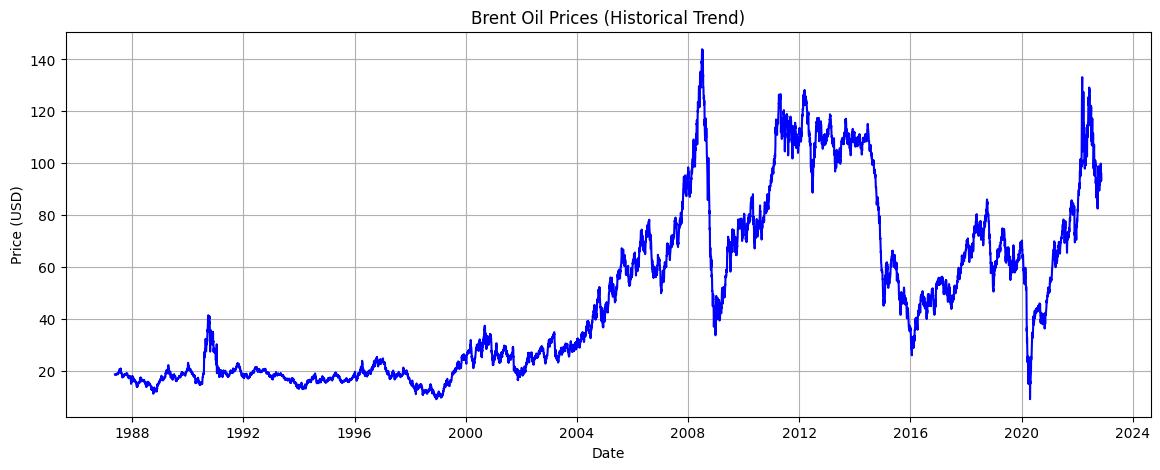

In [3]:
plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Price'], color='blue')
plt.title("Brent Oil Prices (Historical Trend)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()


### Daily Returns and Stationarity Testing

- Compute daily returns to measure relative price changes.  
- Test if returns are stationary using the Augmented Dickey-Fuller (ADF) test.  
- Stationarity is important for change point modeling.


### Returns & ADF Test

In [4]:
# Compute daily returns
df['returns'] = df['Price'].pct_change()

# Drop missing values
returns = df['returns'].dropna()

# ADF Test
adf_result = adfuller(returns)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Returns are stationary (reject H0)")
else:
    print("Returns are non-stationary (fail to reject H0)")


ADF Statistic: -17.11168481990272
p-value: 7.358230367030982e-30
Returns are stationary (reject H0)


### Rolling Volatility

- Calculate 30-day rolling volatility of returns.  
- High volatility may indicate market stress or regime shifts.  
- Visualizing volatility helps identify potential change points.


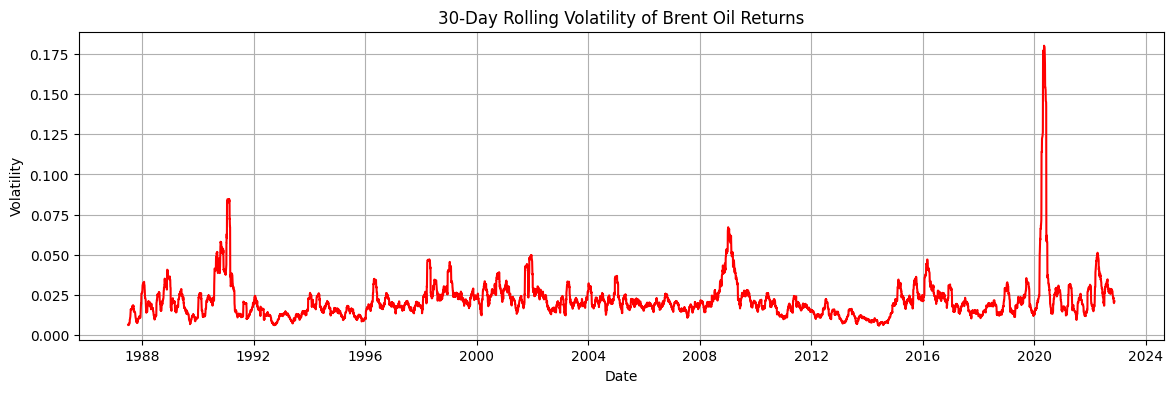

In [5]:
# 30-day rolling volatility
df['volatility'] = df['returns'].rolling(30).std()

plt.figure(figsize=(14,4))
plt.plot(df['Date'], df['volatility'], color='red')
plt.title("30-Day Rolling Volatility of Brent Oil Returns")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()


### Insights for Task 1 Report

- **Trend Analysis:** Long-term trends and sharp price changes are visible, often linked to geopolitical or economic events.  
- **Stationarity:** Returns are stationary, confirming suitability for modeling price shifts.  
- **Volatility:** Periods of high volatility coincide with crises (e.g., COVID-19, oil price wars).  
- These observations justify using Bayesian change point models .


### Save Cleaned Data for Modeling

In [6]:
# Save cleaned data for later modeling
df.to_csv("../data/processed/BrentOilPrices_clean.csv", index=False)
